# Class 1 — Returns, Risk, and Downside Risk

S&P 500 returns, non-normality, historical volatility, downside quantiles, and quantile regression.

**Teaching note.** This notebook is intended to be run from top to bottom. Reusable data-loading and helper routines are in `course_tools.py`.


## Setup


# Stock Prices, Market Indices, and Interest-Rate Data

This notebook uses the helper functions in `course_tools_general.py` to download
financial-market data from **Yahoo Finance** and **FRED (Federal Reserve Economic Data)**.

---

## Common Yahoo Finance Tickers

### U.S. Stocks and Market Indices

| Company / Market | Yahoo Finance Ticker | Suggested Start Date |
|---|---:|---:|
| S&P 500 Index | `^GSPC` | `1960-01-01` |
| Dow Jones Industrial Average | `^DJI` | `1960-01-01` |
| Nasdaq Composite | `^IXIC` | `1971-01-01` |
| Apple | `AAPL` | `1980-01-01` |
| Microsoft | `MSFT` | `1986-01-01` |
| Amazon | `AMZN` | `1997-01-01` |
| NVIDIA | `NVDA` | `1999-01-01` |
| Alphabet / Google | `GOOG` | `2004-01-01` |
| Alphabet Class A | `GOOGL` | `2004-01-01` |
| Meta / Facebook | `META` | `2012-01-01` |
| Tesla | `TSLA` | `2010-01-01` |
| JPMorgan Chase | `JPM` | `1980-01-01` |
| Bank of America | `BAC` | `1980-01-01` |
| Goldman Sachs | `GS` | `1999-01-01` |
| Coca-Cola | `KO` | `1960-01-01` |
| IBM | `IBM` | `1960-01-01` |
| Walmart | `WMT` | `1970-01-01` |
| ExxonMobil | `XOM` | `1960-01-01` |
| Ford | `F` | `1960-01-01` |
| Disney | `DIS` | `1960-01-01` |
| Berkshire Hathaway Class B | `BRK-B` | `1996-01-01` |

---

## Major International Stock-Market Indices

| Country / Market | Yahoo Finance Ticker | Suggested Start Date |
|---|---:|---:|
| United States — S&P 500 | `^GSPC` | `1960-01-01` |
| United Kingdom — FTSE 100 | `^FTSE` | `1984-01-01` |
| Germany — DAX | `^GDAXI` | `1988-01-01` |
| France — CAC 40 | `^FCHI` | `1988-01-01` |
| Euro Area — Euro Stoxx 50 | `^STOXX50E` | `1990-01-01` |
| Japan — Nikkei 225 | `^N225` | `1965-01-01` |
| Hong Kong — Hang Seng | `^HSI` | `1980-01-01` |
| Australia — S&P/ASX 200 | `^AXJO` | `1992-01-01` |
| Canada — S&P/TSX Composite | `^GSPTSE` | `1980-01-01` |
| Brazil — Bovespa | `^BVSP` | `1993-01-01` |
| Mexico — IPC | `^MXX` | `1991-01-01` |
| India — BSE Sensex | `^BSESN` | `1990-01-01` |

---

## Examples of International Individual Stocks

| Company | Market | Yahoo Finance Ticker |
|---|---|---:|
| Toyota | Tokyo | `7203.T` |
| Sony | Tokyo | `6758.T` |
| HSBC | London | `HSBA.L` |
| BP | London | `BP.L` |
| Shell | London | `SHEL.L` |
| SAP | Germany | `SAP.DE` |
| Siemens | Germany | `SIE.DE` |
| BMW | Germany | `BMW.DE` |
| LVMH | Paris | `MC.PA` |
| Airbus | Paris | `AIR.PA` |
| Nestlé | Switzerland | `NESN.SW` |
| Novartis | Switzerland | `NOVN.SW` |
| Toyota ADR | United States | `TM` |
| Alibaba ADR | United States | `BABA` |
| Taiwan Semiconductor ADR | United States | `TSM` |

---

# Interest Rates and Credit-Risk Measures

Interest-rate data can be obtained from either **Yahoo Finance** or **FRED**.

Treasury yields are available from both sources. The Federal Funds rate and
corporate bond yields and spreads are generally better obtained from FRED.

| Interest Rate / Risk Measure | Yahoo Finance Ticker | FRED Series | Suggested Start Date | Preferred Source |
|---|---:|---:|---:|---|
| Effective Federal Funds Rate | — | `DFF` | `1954-07-01` | FRED |
| 5-Year Treasury Yield | `^FVX` | `DGS5` | `1962-01-01` | Either |
| 10-Year Treasury Yield | `^TNX` | `DGS10` | `1962-01-01` | Either |
| 30-Year Treasury Yield | `^TYX` | `DGS30` | `1977-01-01` | Either |
| Moody's Aaa Corporate Bond Yield | — | `DAAA` | `1983-01-01` | FRED |
| Moody's Baa Corporate Bond Yield | — | `DBAA` | `1983-01-01` | FRED |
| Baa Corporate Spread over 10-Year Treasury | — | `BAA10Y` | `1986-01-01` | FRED |
| ICE BofA 7–10 Year U.S. Corporate Bond Yield | — | `BAMLC4A0C710YEY` | `2023-08-28` | FRED |

---

## Using Yahoo Finance

Stock prices, market indices, and Treasury yields available through Yahoo Finance
can be downloaded with the `load_prices()` function.

First import the function:

```python
from course_tools_general import load_prices
```

Choose a ticker and a starting date:

```python
ticker = "AAPL"
start = "2000-01-01"

stock = load_prices(
    ticker=ticker,
    start=start
)
```

For example, the 10-year Treasury yield can be downloaded with

```python
start = "1990-01-01"

treasury10_yahoo = load_prices(
    ticker="^TNX",
    start=start
)
```

The 5-year Treasury yield can be downloaded with

```python
treasury5_yahoo = load_prices(
    ticker="^FVX",
    start=start
)
```

Useful Yahoo Finance interest-rate tickers include:

| Treasury Series | Yahoo Finance Ticker |
|---|---:|
| 13-Week Treasury Bill | `^IRX` |
| 5-Year Treasury Yield | `^FVX` |
| 10-Year Treasury Yield | `^TNX` |
| 30-Year Treasury Yield | `^TYX` |

---

## Using FRED

Macroeconomic and interest-rate data from the Federal Reserve Bank of St. Louis
can be downloaded using the `load_fred()` function contained in
`course_tools_general.py`.

**No FRED password or API key is required for this function.**

First import the function:

```python
from course_tools_general import load_fred
```

Choose a starting date:

```python
start = "1990-01-01"
```

The Effective Federal Funds Rate can be downloaded with

```python
fedfunds = load_fred(
    series="DFF",
    start=start
)
```

The 5-year Treasury yield can be downloaded with

```python
treasury5 = load_fred(
    series="DGS5",
    start=start
)
```

The 10-year Treasury yield can be downloaded with

```python
treasury10 = load_fred(
    series="DGS10",
    start=start
)
```

The Moody's Baa corporate bond yield can be downloaded with

```python
baa_yield = load_fred(
    series="DBAA",
    start=start
)
```

A useful measure of financial-market and credit risk is the Baa corporate
bond yield spread over the 10-year Treasury yield:

```python
credit_spread = load_fred(
    series="BAA10Y",
    start=start
)
```

Several FRED series can be downloaded using the same starting date:

```python
from course_tools_general import load_fred

start = "1990-01-01"

fedfunds      = load_fred("DFF", start)
treasury5     = load_fred("DGS5", start)
treasury10    = load_fred("DGS10", start)
baa_yield     = load_fred("DBAA", start)
credit_spread = load_fred("BAA10Y", start)
```

Useful FRED series include:

| Interest Rate / Risk Measure | FRED Series |
|---|---:|
| Effective Federal Funds Rate | `DFF` |
| 5-Year Treasury Yield | `DGS5` |
| 10-Year Treasury Yield | `DGS10` |
| 30-Year Treasury Yield | `DGS30` |
| Moody's Aaa Corporate Bond Yield | `DAAA` |
| Moody's Baa Corporate Bond Yield | `DBAA` |
| Baa Corporate Spread over 10-Year Treasury | `BAA10Y` |

---

## Corporate Bond Yields and Credit Risk

Corporate bond yields reflect both the general level of interest rates and
compensation for credit risk.

A corporate bond yield may therefore rise because Treasury interest rates rise,
because investors perceive greater corporate default risk, or because both occur.

The **Baa corporate bond spread over the 10-year Treasury**, `BAA10Y`, removes
much of the general Treasury interest-rate component. It is therefore particularly
useful as an indicator of **credit and financial-market risk**.

A larger value of `BAA10Y` indicates that investors require a larger premium
to hold Baa corporate bonds rather than U.S. Treasury securities.

For example:

```python
credit_spread = load_fred(
    series="BAA10Y",
    start="1990-01-01"
)
```

The ICE BofA 7–10 Year U.S. Corporate Bond Yield provides a corporate yield
with a maturity relatively close to that of the 10-year Treasury:

```python
corporate10 = load_fred(
    series="BAMLC4A0C710YEY",
    start="2023-08-28"
)
```

For longer historical analysis, the Moody's Baa yield (`DBAA`) and the
Baa–Treasury spread (`BAA10Y`) are generally more useful.

---

## Note on Start Dates

The start dates shown in the tables are convenient dates for requesting data.
They do **not** have to coincide exactly with the first observation available
from Yahoo Finance or FRED.

The starting date is chosen by the user and can be changed for each exercise.

For example:

```python
start = "2000-01-01"
```

or

```python
start = "2015-01-01"
```

If the requested start date is earlier than the available history of a series,
the downloaded data will begin with the earliest observation available from
that source.

For example, for Apple:

```python
ticker = "AAPL"
start = "1960-01-01"

stock = load_prices(
    ticker=ticker,
    start=start
)
```

Apple did not trade publicly in 1960. Yahoo Finance will therefore return
Apple data beginning with the earliest available observations rather than
creating observations for earlier years.

The same principle applies to FRED data. For example:

```python
start = "1950-01-01"

treasury10 = load_fred(
    series="DGS10",
    start=start
)
```

If the FRED series begins after 1950, the returned data will simply begin with
the first available observation.
    

# Foreign Exchange Rates Against the U.S. Dollar

Foreign-exchange rates can be downloaded from both **Yahoo Finance** and **FRED (Federal Reserve Economic Data)**.

Yahoo Finance is convenient because exchange rates can be downloaded using the same `load_prices()` function used for stocks and market indices.

FRED provides official Federal Reserve exchange-rate series and is especially useful for historical analysis.

---

## Exchange-Rate Quote Conventions

An important point is that exchange rates are not always quoted in the same direction.

For example,

$$
\text{USD/EUR} = 1.15
$$

means that

$$
1\text{ euro} = 1.15\text{ U.S. dollars}.
$$

By contrast,

$$
\text{JPY/YEN} = 150
$$

means that

$$
1\text{ U.S. dollar} = 150\text{ Japanese yen}.
$$

Therefore, always check the **quote convention** before interpreting an increase or decrease in an exchange rate.

---

## Major Exchange Rates

| Currency / Country               | Yahoo Finance Ticker | FRED Series | Quote Convention | Suggested Start Date | Preferred Source |
| -------------------------------- | -------------------- | ----------- | ---------------- | -------------------- | ---------------- |
| Euro Area — Euro                 | `EURUSD=X`           | `DEXUSEU`   | USD per EUR      | `1999-01-01`         | Either           |
| United Kingdom — Pound Sterling  | `GBPUSD=X`           | `DEXUSUK`   | USD per GBP      | `1971-01-01`         | Either           |
| Japan — Yen                      | `JPY=X`              | `DEXJPUS`   | JPY per USD      | `1971-01-01`         | Either           |
| Canada — Canadian Dollar         | `CAD=X`              | `DEXCAUS`   | CAD per USD      | `1971-01-01`         | Either           |
| Switzerland — Swiss Franc        | `CHF=X`              | `DEXSZUS`   | CHF per USD      | `1971-01-01`         | Either           |
| Australia — Australian Dollar    | `AUDUSD=X`           | `DEXUSAL`   | USD per AUD      | `1971-01-01`         | Either           |
| New Zealand — New Zealand Dollar | `NZDUSD=X`           | `DEXUSNZ`   | USD per NZD      | `1971-01-01`         | Either           |
| China — Yuan Renminbi            | `CNY=X`              | `DEXCHUS`   | CNY per USD      | `1981-01-01`         | FRED             |
| Hong Kong — Hong Kong Dollar     | `HKD=X`              | `DEXHKUS`   | HKD per USD      | `1981-01-01`         | Either           |
| Singapore — Singapore Dollar     | `SGD=X`              | `DEXSIUS`   | SGD per USD      | `1981-01-01`         | Either           |
| South Korea — Won                | `KRW=X`              | `DEXKOUS`   | KRW per USD      | `1981-01-01`         | FRED             |
| India — Rupee                    | `INR=X`              | `DEXINUS`   | INR per USD      | `1973-01-01`         | FRED             |
| Mexico — Peso                    | `MXN=X`              | `DEXMXUS`   | MXN per USD      | `1993-01-01`         | Either           |
| Brazil — Real                    | `BRL=X`              | `DEXBZUS`   | BRL per USD      | `1995-01-01`         | Either           |
| Thailand — Baht                  | `THB=X`              | `DEXTHUS`   | THB per USD      | `1981-01-01`         | FRED             |
| Malaysia — Ringgit               | `MYR=X`              | `DEXMAUS`   | MYR per USD      | `1971-01-01`         | FRED             |
| Philippines — Peso               | `PHP=X`              | —           | PHP per USD      | `2000-01-01`         | Yahoo            |

---

# Using Yahoo Finance for Exchange Rates

Exchange rates from Yahoo Finance can be downloaded with the same `load_prices()` function used for stock prices and market indices.

First import the function:

```python
from course_tools_general import load_prices
```

For example, the euro-dollar exchange rate can be downloaded with

```python
euro = load_prices(
    ticker="EURUSD=X",
    start="2000-01-01"
)
```

The Yahoo ticker

```text
EURUSD=X
```

is quoted as

$$
\frac{\text{U.S. dollars}}{\text{euro}}.
$$

Therefore,

$$
\Delta(\text{EUR/USD}) > 0
$$

represents an **appreciation of the euro** and a **depreciation of the U.S. dollar**.

---

## Japanese Yen

The Japanese yen can be downloaded with

```python
yen = load_prices(
    ticker="JPY=X",
    start="2000-01-01"
)
```

This exchange rate is quoted as

$$
\frac{\text{Japanese yen}}{\text{U.S. dollar}}.
$$

Therefore,

$$
\Delta(\text{JPY per USD}) > 0
$$

represents an **appreciation of the U.S. dollar** and a **depreciation of the Japanese yen**.

---

## Philippine Peso

The Philippine peso can be downloaded with

```python
peso_ph = load_prices(
    ticker="PHP=X",
    start="2000-01-01"
)
```

This series is quoted as

$$
\frac{\text{Philippine pesos}}{\text{U.S. dollar}}.
$$

Thus,

$$
\Delta(\text{PHP per USD}) > 0
$$

represents a **depreciation of the Philippine peso** against the U.S. dollar.

---

## Downloading Several Yahoo Exchange Rates

Several exchange rates can be downloaded using the same starting date:

```python
from course_tools_general import load_prices

start = "2000-01-01"

euro    = load_prices("EURUSD=X", start)
pound   = load_prices("GBPUSD=X", start)
yen     = load_prices("JPY=X", start)
canada  = load_prices("CAD=X", start)
yuan    = load_prices("CNY=X", start)
rupee   = load_prices("INR=X", start)
peso_mx = load_prices("MXN=X", start)
peso_ph = load_prices("PHP=X", start)
```

---

# Using FRED for Exchange Rates

Daily foreign-exchange rates from the Federal Reserve can be downloaded with the `load_fred()` function contained in `course_tools_general.py`.

First import the function:

```python
from course_tools_general import load_fred
```

For example, the euro-dollar exchange rate can be downloaded with

```python
start = "2000-01-01"

euro_fred = load_fred(
    series="DEXUSEU",
    start=start
)
```

The FRED series `DEXUSEU` is quoted as

$$
\frac{\text{U.S. dollars}}{\text{euro}}.
$$

---

## Japanese Yen from FRED

The Japanese yen can be downloaded with

```python
yen_fred = load_fred(
    series="DEXJPUS",
    start=start
)
```

This series is quoted as

$$
\frac{\text{Japanese yen}}{\text{U.S. dollar}}.
$$

---

## Chinese Yuan from FRED

The Chinese yuan can be downloaded with

```python
yuan_fred = load_fred(
    series="DEXCHUS",
    start=start
)
```

This series is quoted as

$$
\frac{\text{Chinese yuan}}{\text{U.S. dollar}}.
$$

---

## Downloading Several FRED Exchange Rates

Several exchange rates can be downloaded using the same starting date:

```python
from course_tools_general import load_fred

start = "2000-01-01"

euro_fred   = load_fred("DEXUSEU", start)
pound_fred  = load_fred("DEXUSUK", start)
yen_fred    = load_fred("DEXJPUS", start)
canada_fred = load_fred("DEXCAUS", start)
swiss_fred  = load_fred("DEXSZUS", start)
yuan_fred   = load_fred("DEXCHUS", start)
won_fred    = load_fred("DEXKOUS", start)
rupee_fred  = load_fred("DEXINUS", start)
mexico_fred = load_fred("DEXMXUS", start)
brazil_fred = load_fred("DEXBZUS", start)
```

---

# Broad U.S. Dollar Index

Rather than examining the U.S. dollar against a single foreign currency, it is sometimes useful to use a trade-weighted measure of the dollar.

FRED provides the **Nominal Broad U.S. Dollar Index**.

| Measure                         | FRED Series | Suggested Start Date |
| ------------------------------- | ----------- | -------------------- |
| Nominal Broad U.S. Dollar Index | `DTWEXBGS`  | `2006-01-01`         |

It can be downloaded with

```python
dollar_index = load_fred(
    series="DTWEXBGS",
    start="2006-01-01"
)
```

An increase in this index represents a broad **appreciation of the U.S. dollar** against the currencies of major U.S. trading partners.

Symbolically,

$$
\Delta(\text{Dollar Index}) > 0
$$

indicates an appreciation of the U.S. dollar.

---

# Exchange-Rate Changes and Returns

For financial analysis, it is often more useful to examine the percentage change in an exchange rate rather than its level.

Let the exchange rate at date \(t\) be denoted by

$$
S_t.
$$

A continuously compounded exchange-rate return is

$$
r_t^{FX}
=
100
\left[
\ln(S_t)-\ln(S_{t-1})
\right].
$$

Equivalently,

$$
r_t^{FX}
=
100
\ln
\left(
\frac{S_t}{S_{t-1}}
\right).
$$

In Python this can be calculated with

```python
import numpy as np

euro["FX_Return"] = (
    100 * np.log(euro["Price"]).diff()
)
```

or equivalently,

```python
euro["FX_Return"] = (
    100 * np.log(
        euro["Price"] / euro["Price"].shift(1)
    )
)
```

---

# Interpretation of Exchange-Rate Returns

The interpretation of $(r_t^{FX}$ depends on the quote convention.

For the euro,

$$
S_t
=
\frac{\text{USD}}{\text{EUR}}.
$$

Therefore,

$$
r_t^{FX} > 0
$$

means that the **euro appreciated** and the **U.S. dollar depreciated**.

For the Japanese yen,

$$
S_t
=
\frac{\text{JPY}}{\text{USD}}.
$$

Therefore,

$$
r_t^{FX} > 0
$$

means that the **U.S. dollar appreciated** and the **Japanese yen depreciated**.

This distinction is important when comparing exchange-rate movements across countries.

---

# A Common Exchange-Rate Convention

For cross-country empirical work, it is often convenient to express all exchange rates using the same convention:

$$
S_t
=
\frac{\text{units of foreign currency}}{\text{U.S. dollar}}.
$$

Under this convention,

$$
\Delta S_t > 0
$$

means that the foreign currency has **depreciated** against the U.S. dollar.

Conversely,

$$
\Delta S_t < 0
$$

means that the foreign currency has **appreciated** against the U.S. dollar.

Most FRED bilateral exchange-rate series use this convention.

Some important exceptions are the euro, British pound, Australian dollar, and New Zealand dollar, which are normally quoted as

$$
\frac{\text{U.S. dollars}}{\text{unit of foreign currency}}.
$$

These exchange rates can be inverted if a common convention is desired.

For example, suppose the euro series is

$$
S_t^{EUR}
=
\frac{\text{USD}}{\text{EUR}}.
$$

Then define

$$
\widetilde{S}_t^{EUR}
=
\frac{1}{S_t^{EUR}}
=
\frac{\text{EUR}}{\text{USD}}.
$$

In Python:

```python
euro["EUR_per_USD"] = 1 / euro["Price"]
```

With this convention,

$$
\Delta \widetilde{S}_t^{EUR} > 0
$$

indicates a **depreciation of the euro** against the U.S. dollar.


In [15]:
import course_tools_general as ctg


# Download data for any ticker directly into your target variable
spx = ctg.load_prices(ticker="^GSPC", start="1990-01-01")
spx.head()


Price,Close,High,Low,Open,Volume,Log_Close,Log_Open,Log_High,Log_Low,Return
Date,,,,,,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000,5.885243,5.867601,5.885243,5.863574,NaN
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000,5.882654,5.885243,5.887742,5.880226,-0.002589
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000,5.874003,5.882654,5.882654,5.866156,-0.008650
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000,5.864199,5.874003,5.874003,5.861783,-0.009804
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000,5.868704,5.864199,5.869975,5.859475,0.004504


In [43]:


start = "1990-01-01"

fedfunds      = ctg.load_fred("DFF", start)
treasury5     = ctg.load_fred("DGS5", start)
treasury10    = ctg.load_fred("DGS10", start)
baa_yield     = ctg.load_fred("DBAA", start)
credit_spread = ctg.load_fred("BAA10Y", start)

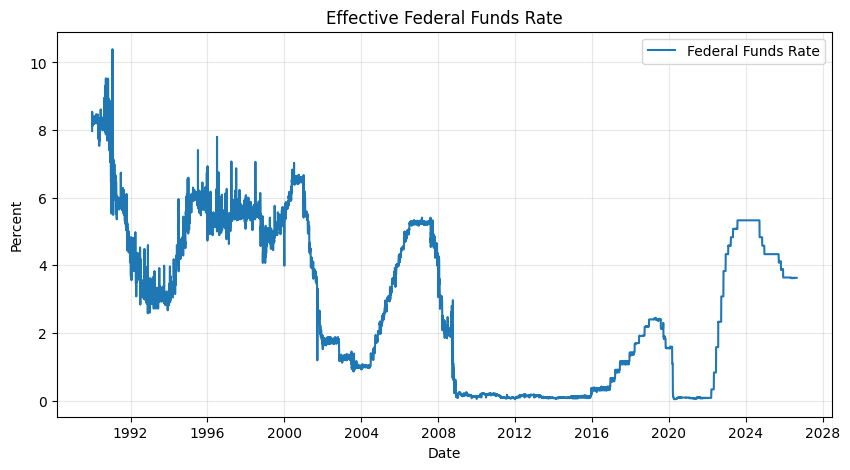

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    fedfunds.index,
    fedfunds["DFF"],
    label="Federal Funds Rate"
)

plt.title("Effective Federal Funds Rate")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [45]:
[len(fedfunds), len(spx)]

[13387, 9231]

In [46]:
fedfunds_spx = fedfunds.reindex(spx.index).ffill()

# Introduction:  All About Returns and Volatility
- Both returns and risk matter for financial decisions
- Returns are easy to measure:  just the rate of growth of the share price plus dividend payments (if any), adjusted for inflation 
- Risk is a different matter, it is a \textbf{latent variable}.
- We discussis several measures of risk:  the moving-window standard deviation, range volatility (obtained for daily, high, low, open and closing prices)  and conditonal volatility (obtained from econometric estimation).
- All of these measures can be used as a "thick measure" for underlying risk.
- 
## Introduction:  Standard and Poor 500 Data

- We will first read in the Standard and Poor data series from 1960 in daily format
- We take the data for open, high, low and close
- We will take logs of the data and first differences of the log of the closing price to get daily returns
- We also create dummies for days of the week.


## Plot of the Logarithmic Level
- In the chart below be plot the log of the levels
- You can see that it is not stationary, that its mean is rising
- We cannot say much about any variable with a rising mean

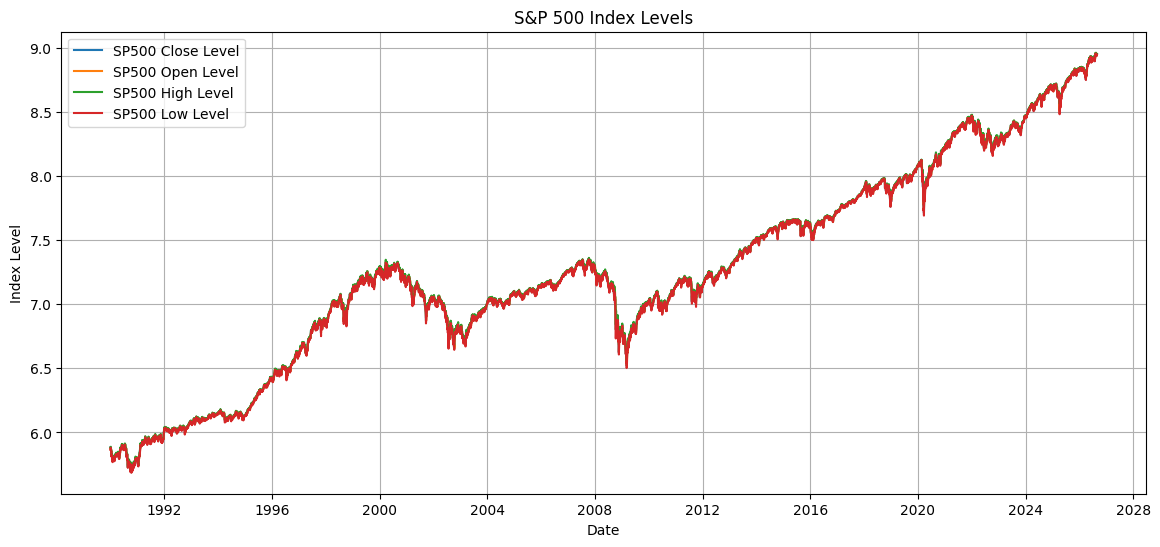

In [47]:
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera
plt.figure(figsize=(14, 6))
plt.title("S&P 500 Index Levels")
plt.plot(spx['Log_Close'], label='SP500 Close Level')
plt.plot(spx['Log_Open'], label='SP500 Open Level')
plt.plot(spx['Log_High'], label='SP500 High Level')
plt.plot(spx['Log_Low'], label='SP500 Low Level')
plt.xlabel('Date')
plt.ylabel('Index Level')
plt.legend()
plt.grid()
plt.show()

## Plot of Daily Returns
- We plot the daily returns or the logarithmic first differences
- We see that there are periods of high and low or normal volatility
- Variance is not constant
- For the linear OLS model we assume that the stochastic term has constant mean and constant variance.  
- This is obviously not true for asset-market returns.
- Exercise:  read in data for other share-market prices, exchange rates or commodity prices.  

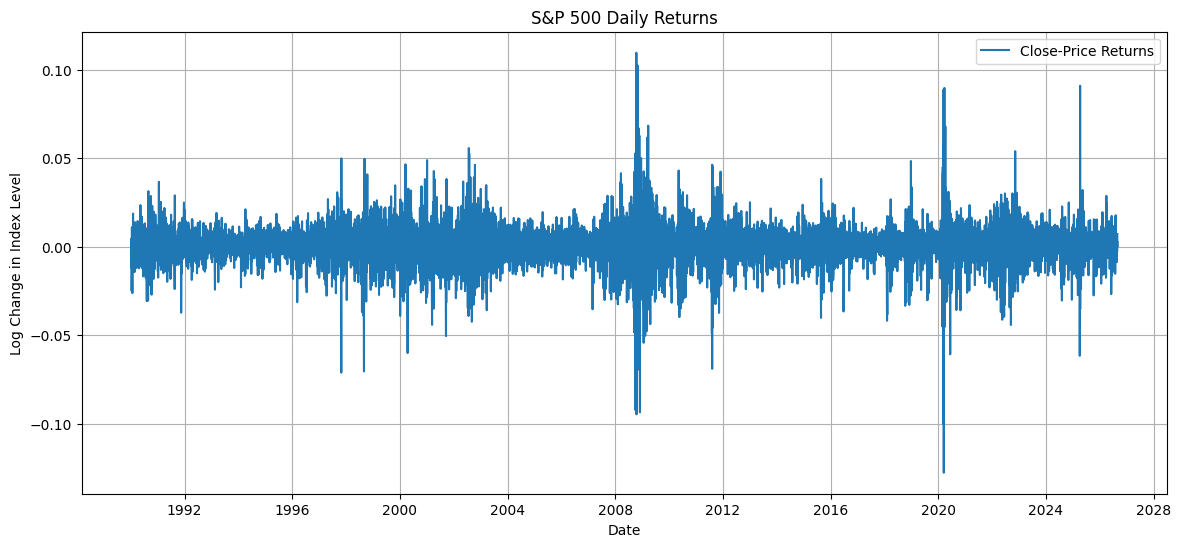

In [48]:
plt.figure(figsize=(14, 6))
plt.title("S&P 500 Daily Returns")
plt.plot(spx['Return'], label='Close-Price Returns')
plt.xlabel('Date')
plt.ylabel('Log Change in Index Level')
plt.legend()
plt.grid()
plt.show()

## Non-Normality
- We plot the histogram of the asset returns
- We see that there is a big peak in the middle and fat tails on the left side
- We call these properties skewness and kurtosis
- The Jarque Bera test is a test of normailty
- If the returns were normally distributed the skewness should be zero and the kurtosis should be 3
- We see that there is negative skewness and excess kurtosis

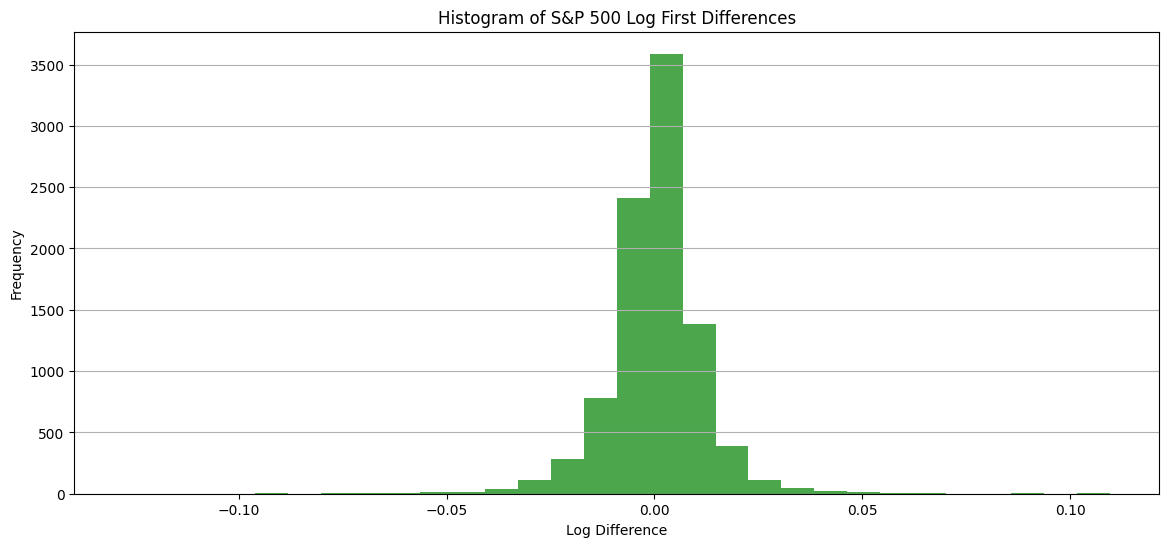

JB Statistic for Log First Differences: 45656.525312255086, p-value: 0.0


In [25]:
#import pandas_datareader.data as web
from datetime import date, timedelta
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import jarque_bera

# Histogram for Log First Differences
plt.figure(figsize=(14, 6))
plt.title("Histogram of S&P 500 Log First Differences")
plt.hist(spx['Return'].dropna(), bins=30, color='green', alpha=0.7)
plt.xlabel('Log Difference')
plt.ylabel('Frequency')
plt.grid(axis='y')
plt.show()

# Jarque-Bera Test for Log First Differences

jb_stats_log_diff = jarque_bera(spx['Return'].dropna())
print(f"JB Statistic for Log First Differences: {jb_stats_log_diff.statistic}, p-value: {jb_stats_log_diff.pvalue}")

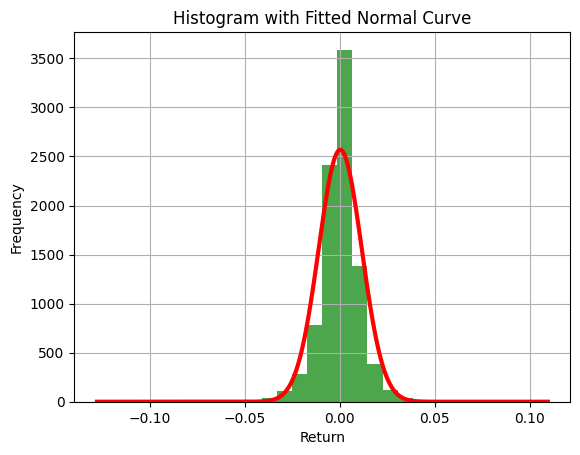

In [23]:
from scipy.stats import norm

r = spx['Return'].dropna()

mu, sigma = norm.fit(r)

counts, bins, _ = plt.hist(
    r,
    bins=30,
    color='green',
    alpha=0.7
)

bin_width = bins[1] - bins[0]

x = np.linspace(bins[0], bins[-1], 500)

plt.plot(
    x,
    norm.pdf(x, mu, sigma) * len(r) * bin_width,
    'r',
    linewidth=3
)

plt.title("Histogram with Fitted Normal Curve")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

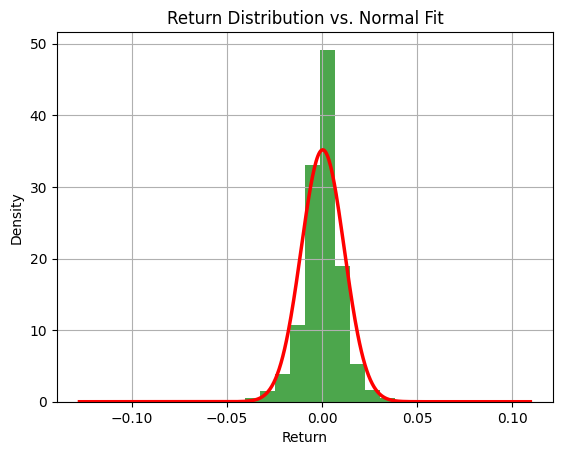

In [26]:
# Alternative approach using density=True
from scipy.stats import norm

r = spx['Return'].dropna()

mu, sigma = norm.fit(r)
# Alternative approach using density=True
plt.hist(r, bins=30, density=True, color='green', alpha=0.7)

# Now you can plot the PDF directly without extra scaling math
x = np.linspace(r.min(), r.max(), 500)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2.5)

plt.title("Return Distribution vs. Normal Fit")
plt.xlabel("Return")
plt.ylabel("Density")
plt.grid(True)
plt.show()

In [27]:
from scipy.stats import jarque_bera, skew, kurtosis
import pandas as pd
import numpy as np

# Clean return series
returns = spx['Return'].dropna()

# Summary statistics
summary_stats = pd.DataFrame({
    'Statistic': [
        'Mean',
        'Variance',
        'Skewness',
        'Kurtosis',
        'Jarque-Bera Statistic',
        'JB p-value'
    ],
    'Value': [
        returns.mean(),
        returns.var(),
        skew(returns),
        kurtosis(returns, fisher=False),  # Normal distribution = 3
        jarque_bera(returns).statistic,
        jarque_bera(returns).pvalue
    ]
})

print(summary_stats.round(6))

               Statistic         Value
0                   Mean      0.000332
1               Variance      0.000129
2               Skewness     -0.364170
3               Kurtosis     13.871356
4  Jarque-Bera Statistic  45656.525312
5             JB p-value      0.000000


## Annualized Capital-Gains Return on Equity
- The daily returns have to be annualized in order to make any sense
- We do this with the formula below
- We see that the mean equity annualized return is about 7.5 percent
- This return excludes dividend payments and does not adjust for inflation
- This is a realistic nominal return.  

In [49]:
annualized_capital_gains_return = (1 + spx['Return'].mean())**250 - 1

print(f"Annualized Capital-Gains Return = {annualized_capital_gains_return:}")

Annualized Capital-Gains Return = 0.08662656868275165


In [50]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# Construct daily S&P 500 excess returns
# ---------------------------------------------------------

# 1. Keep only dates for which an S&P return exists
excess = spx[["Return"]].dropna().copy()

# 2. Put the Fed Funds rate onto the S&P trading-day calendar
#    DFF is reported as an annual percentage rate
ff = (
    fedfunds["DFF"]
    .reindex(spx.index)
    .ffill()
)

# 3. Number of CALENDAR days between successive S&P observations
#    Normally 1 day, but 3 days over a weekend, etc.
days = spx.index.to_series().diff().dt.days

# 4. Use the Fed Funds rate prevailing at the START
#    of the S&P return interval
ff_start = ff.shift(1)

# 5. Convert annualized Fed Funds rate into the risk-free
#    return over the actual number of calendar days.
#
#    DFF is in percent, so divide by 100.
#    Money-market convention uses a 360-day year.
rf_simple = (ff_start / 100) * (days / 360)

# Convert the risk-free return to a LOG return,
# because the S&P "Return" variable is a log return.
excess["RF"] = np.log1p(rf_simple)

# 6. Calculate S&P 500 excess log return
excess["Excess_Return"] = (
    excess["Return"] - excess["RF"]
)

# 7. Remove the first missing observation
excess = excess.dropna()

excess.head()

Price,Return,RF,Excess_Return
Date,,,
1990-01-03,-0.002589,0.000237,-0.002826
1990-01-04,-0.008650,0.000232,-0.008883
1990-01-05,-0.009804,0.000230,-0.010034
1990-01-08,0.004504,0.000683,0.003821
1990-01-09,-0.011857,0.000230,-0.012086


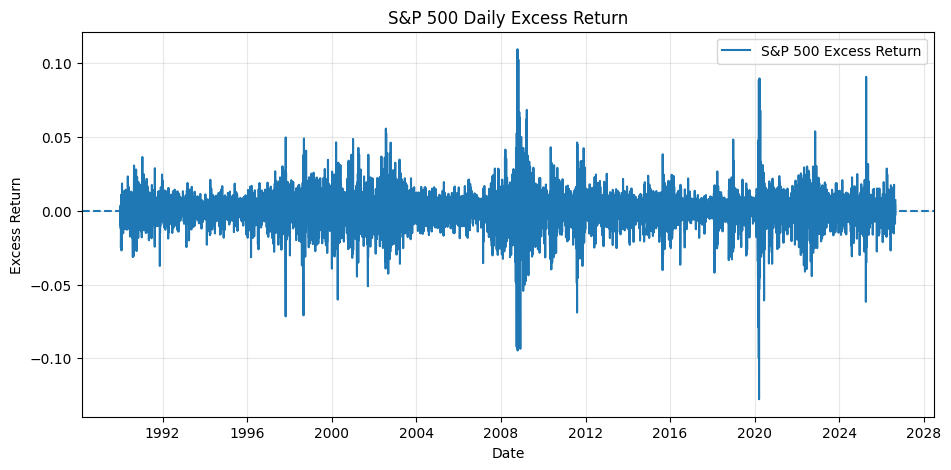

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.plot(
    excess.index,
    excess["Excess_Return"],
    label="S&P 500 Excess Return"
)

plt.axhline(0, linestyle="--")

plt.title("S&P 500 Daily Excess Return")
plt.xlabel("Date")
plt.ylabel("Excess Return")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [52]:
AnnualMean = 250 * excess.mean()
print("Mean annual excess return =", AnnualMean)

Mean annual excess return = Price
Return           0.083092
RF               0.029136
Excess_Return    0.053955
dtype: float64


## The Equity Premium

- The equity risk premium measures the extra return investors demand for holding equities rather than risk-free assets.

- Let $r_t$ denote the return on the S&P 500 and $r_f$ denote the risk-free rate (such as a U.S. Treasury Bill yield).

- The equity risk premium is defined as:
  $$EP_t = r_t - r_f$$

- A positive equity premium reflects compensation for bearing the additional volatility and downside risk associated with stock market investments.

- For example, over the sample period (1960–present), the average annual S&P 500 price return was **8.31%** and the risk-free rate averaged **2.91%**, yielding a net price excess return of **5.40%**. 

- If we incorporate an estimated average dividend yield of **3.00%**, the total annualized equity risk premium increases to approximately **8.40%** ($8.31\% + 3.00\% - 2.91\%$).

- Historically, estimates of the U.S. equity risk premium generally range between **5% and 8%** per year, depending on the sample period, data frequency, and whether returns include dividends.

### Volatility as a Measure of Risk
Different measures of this $\textbf{latent}$ variable.

- Historical volatility
- Range Volatility
- Conditional Volatility
- Implied Volatility

## Historical Volatility (HV)

- Rolling window volatility is one of the most widely used measures of financial market risk.
- It is called the Historical Volatility (HV) measure
- It is commonly displayed on Bloomberg terminals, trading platforms, and risk-management systems.
- The measure is simple to compute and easy to interpret.
- Unlike GARCH-type models, rolling volatility does not require estimation of parameters or assumptions about the dynamics of volatility.
- Instead, it uses only the recent history of returns to estimate current market uncertainty.

- Suppose we observe a series of returns $r_1, r_2, \ldots, r_N$

- For a rolling window of length $h$, we compute the standard deviation using the most recent $h$ observations.

- For example, the first estimate is based on $r_1, r_2, \ldots, r_h$

- The second estimate is based on $r_2, r_3, \ldots, r_{h+1}$

- The process continues until the final window $r_{N-h+1}, \ldots, r_N$

- For each window, the rolling volatility estimate is $\sigma_t=\sqrt{\frac{1}{h-1}\sum_{j=t-h+1}^{t}(r_j-\bar{r}_t)^2}$

- $\bar r_t=\frac{1}{h}\sum_{j=t-h+1}^{t}r_j$ is the mean return within the rolling window.

- The rolling volatility series therefore consists of $
N-h+1$ overlapping volatility estimates.

### Interpretation

- High values indicate periods of elevated uncertainty and risk.
- Low values indicate relatively calm market conditions.
- Volatility tends to cluster over time, meaning that periods of high volatility are often followed by additional periods of high volatility.
- Large spikes in rolling volatility typically coincide with financial crises, recessions, market crashes, or major economic announcements.

### Advantages

- Simple to compute and explain.
- Requires no parameter estimation.
- Easy to update as new data become available.
- Widely used in practice by traders, portfolio managers, and risk managers.

### Limitations

- All observations within the window receive equal weight.
- Information outside the window is discarded completely.
- Volatility estimates can change abruptly when large observations enter or leave the window.
- The choice of window length is arbitrary.

-For example:

- 20-day window: approximately one trading month.
- 60-day window: approximately one quarter.
- 252-day window: approximately one trading year.

-Different window lengths can produce noticeably different volatility estimates.



- Rolling volatility is a backward-looking measure based entirely on recent observations.



- The rolling-window Historical Volatility (HV)measure can be viewed as a simple benchmark against which more sophisticated volatility models are compared.




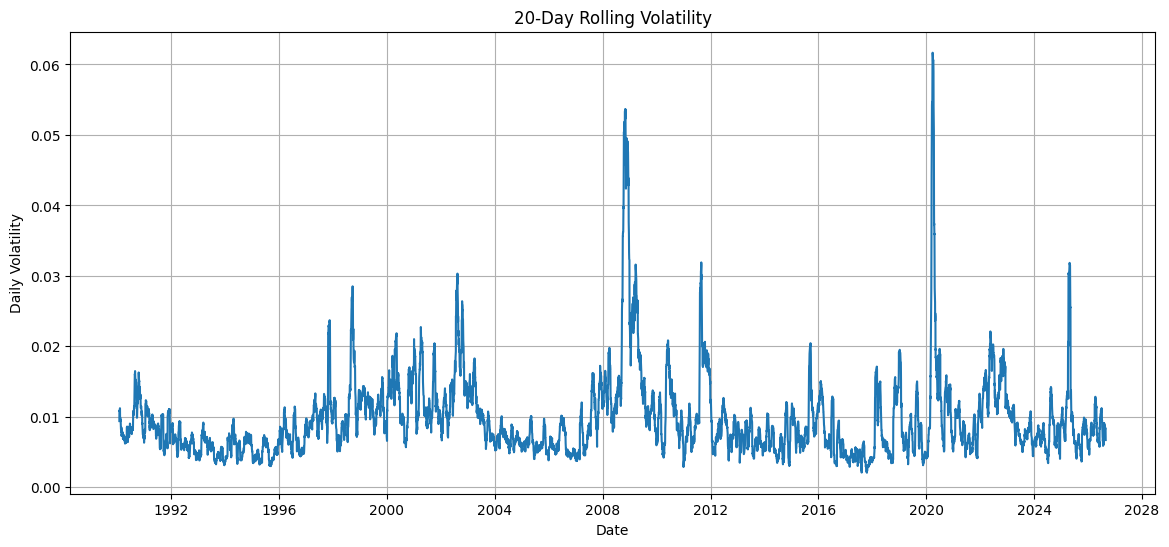

In [53]:
rolling_vol = spx['Return'].rolling(20).std()

plt.figure(figsize=(14,6))
plt.plot(rolling_vol.index, rolling_vol)
plt.title('20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Daily Volatility')
plt.grid(True)
plt.show()

## Downside Risk: Looking Beyond Volatility

Volatility treats unusually large positive and negative returns alike. Investors may care more about the lower tail: the possibility of a large loss.

A simple historical measure is the rolling 5th percentile of returns. Over a 252-trading-day window, it answers:

> What return separates the worst 5% of recent trading days from the other 95%?

If this quantile is $-0.025$, approximately 5% of the returns in that historical window were below $-2.5\%$. A common loss-positive Value-at-Risk convention would report this as $2.5\%$ rather than $-2.5\%$.


### Two Measures of Downside Risk

| Method | Calculation | Distribution Assumed? |
|:--|:--|:--|
| **Historical quantile** | Actual 5th percentile of the previous 252 daily returns | No |
| **Normal VaR** | Rolling mean $- 1.645 \times$ rolling standard deviation | Yes, normally distributed returns |

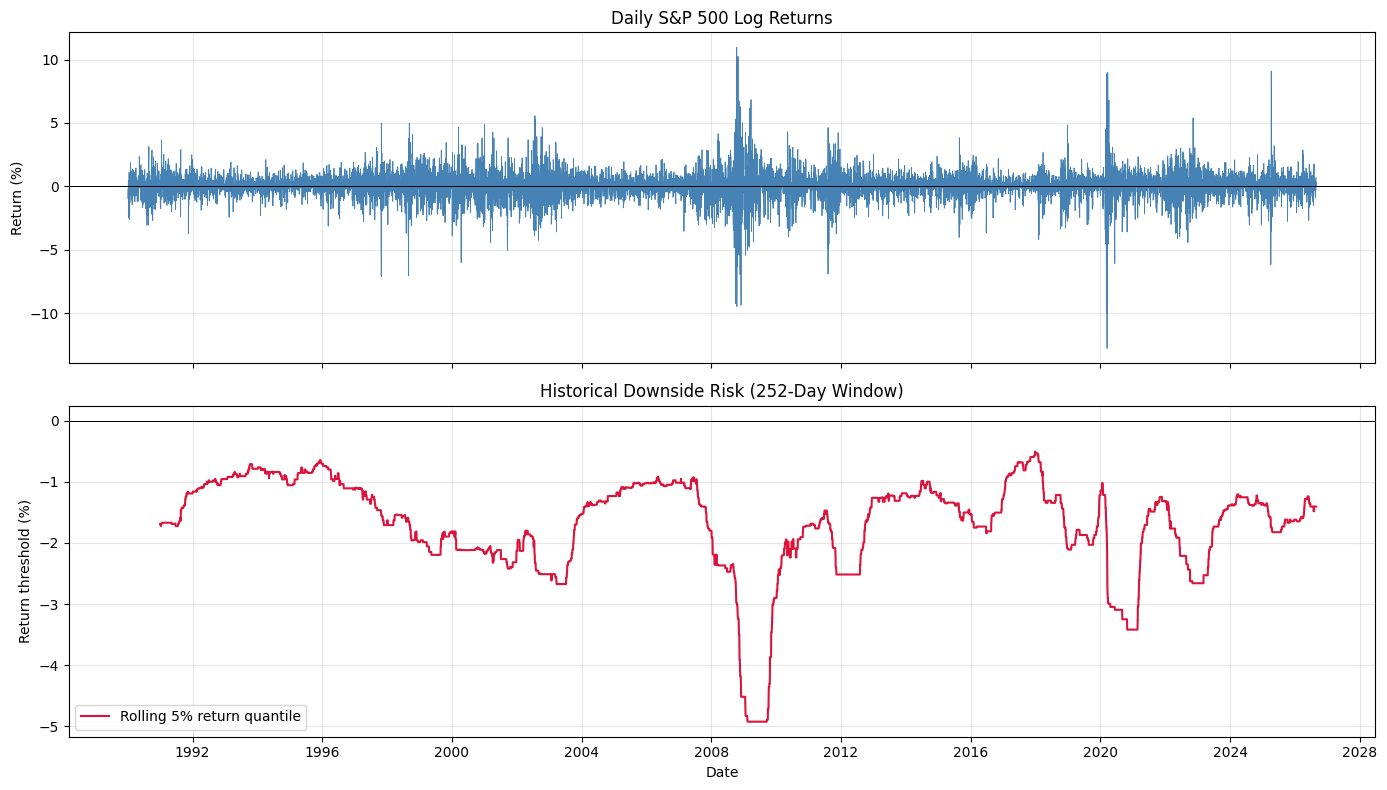

In [54]:
# Historical downside risk: rolling 5% return quantile
window = 252                 # approximately one trading year
alpha = 0.05

spx['Downside_5pct'] = spx['Return'].rolling(window).quantile(alpha)
spx['Historical_VaR_95'] = -spx['Downside_5pct']  # loss-positive reporting convention

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spx.index, 100 * spx['Return'], color='steelblue', linewidth=0.6)
axes[0].axhline(0, color='black', linewidth=0.7)
axes[0].set_title('Daily S&P 500 Log Returns')
axes[0].set_ylabel('Return (%)')
axes[0].grid(alpha=0.3)

axes[1].plot(
    spx.index,
    100 * spx['Downside_5pct'],
    color='crimson',
    label='Rolling 5% return quantile'
)
axes[1].axhline(0, color='black', linewidth=0.7)
axes[1].set_title('Historical Downside Risk (252-Day Window)')
axes[1].set_ylabel('Return threshold (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [55]:
from scipy.stats import norm

window = 252
alpha = 0.05

rolling_mean = spx["Return"].rolling(window).mean()
rolling_std = spx["Return"].rolling(window).std()

z_05 = norm.ppf(alpha)  # approximately -1.645

spx["Normal_Downside_5pct"] = (
    rolling_mean + z_05 * rolling_std
)

spx["Normal_VaR_95"] = -spx["Normal_Downside_5pct"]

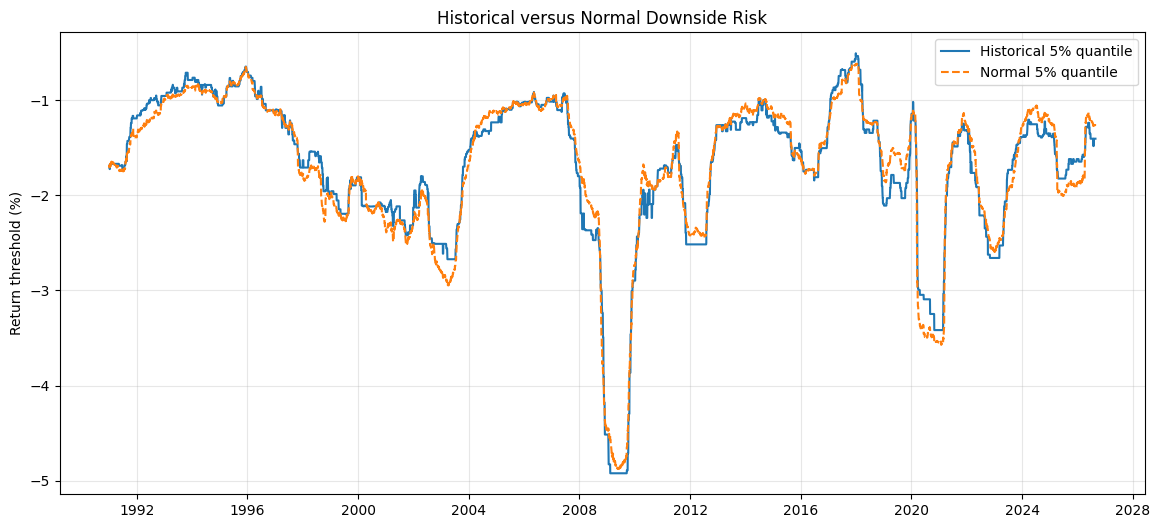

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    spx.index,
    100 * spx["Downside_5pct"],
    label="Historical 5% quantile"
)

plt.plot(
    spx.index,
    100 * spx["Normal_Downside_5pct"],
    label="Normal 5% quantile",
    linestyle="--"
)

plt.ylabel("Return threshold (%)")
plt.title("Historical versus Normal Downside Risk")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Quantile Regression: Does Uncertainty Affect the Downside?

Ordinary least squares describes the conditional **mean** of tomorrow's return. Quantile regression can describe a selected part of the conditional distribution.

We estimate

$$Q_{\tau}(r_{t+1}\mid \sigma_t) = \beta_{0,\tau}+\beta_{1,\tau}\sigma_t,$$

where $\tau=0.05$ describes the lower tail and $\tau=0.50$ describes the median. Today's 20-day volatility is used to explain tomorrow's return, so the predictors contain no future information.

- This is a teaching illustration, not a trading strategy.
- A negative 5% coefficient would mean that greater uncertainty is associated with a more negative conditional downside threshold.
- It does **not** mean that volatility causes losses or estimates the probability of a crash.


In [41]:
import statsmodels.formula.api as smf

# Build a clearly timed data set: information at t predicts the return at t+1.
qr_data = pd.DataFrame(index=spx.index)
qr_data['return_next_pct'] = 100 * spx['Return'].shift(-1)
qr_data['volatility_today_pct'] = 100 * spx['Return'].rolling(20).std()
qr_data = qr_data.dropna()

# Mean, median, and lower-tail models use the same dependent variable and predictor.
ols_mean = smf.ols(
    'return_next_pct ~ volatility_today_pct', data=qr_data
).fit()

qr_median = smf.quantreg(
    'return_next_pct ~ volatility_today_pct', data=qr_data
).fit(q=0.50)

qr_downside = smf.quantreg(
    'return_next_pct ~ volatility_today_pct', data=qr_data
).fit(q=0.05, max_iter=5000)

comparison = pd.DataFrame({
    'Model': ['OLS conditional mean', 'Quantile: median', 'Quantile: lower 5%'],
    'Intercept': [ols_mean.params['Intercept'],
                  qr_median.params['Intercept'],
                  qr_downside.params['Intercept']],
    'Volatility coefficient': [ols_mean.params['volatility_today_pct'],
                               qr_median.params['volatility_today_pct'],
                               qr_downside.params['volatility_today_pct']],
    'Volatility p-value': [ols_mean.pvalues['volatility_today_pct'],
                           qr_median.pvalues['volatility_today_pct'],
                           qr_downside.pvalues['volatility_today_pct']]
})

display(comparison.round(4))


,Model,Intercept,Volatility coefficient,Volatility p-value
0,OLS conditional mean,0.0233,0.0115,0.5574
1,Quantile: median,0.0337,0.0362,0.0135
2,Quantile: lower 5%,-0.3041,-1.3962,0.0000


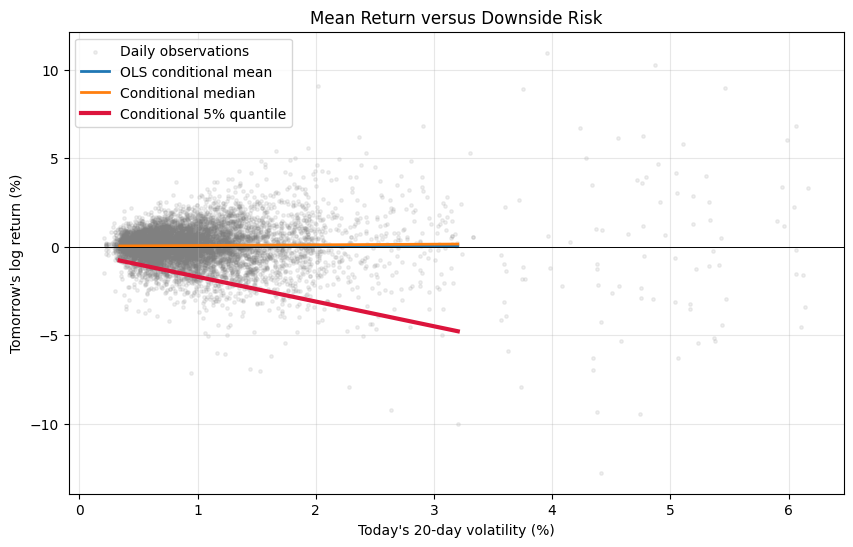

In [42]:
vol_grid = pd.DataFrame({
    'volatility_today_pct': np.linspace(
        qr_data['volatility_today_pct'].quantile(0.01),
        qr_data['volatility_today_pct'].quantile(0.99),
        100
    )
})

plt.figure(figsize=(10, 6))
plt.scatter(
    qr_data['volatility_today_pct'],
    qr_data['return_next_pct'],
    s=6, alpha=0.12, color='gray', label='Daily observations'
)
plt.plot(vol_grid['volatility_today_pct'], ols_mean.predict(vol_grid),
         linewidth=2, label='OLS conditional mean')
plt.plot(vol_grid['volatility_today_pct'], qr_median.predict(vol_grid),
         linewidth=2, label='Conditional median')
plt.plot(vol_grid['volatility_today_pct'], qr_downside.predict(vol_grid),
         linewidth=3, color='crimson', label='Conditional 5% quantile')
plt.axhline(0, color='black', linewidth=0.7)
plt.xlabel("Today's 20-day volatility (%)")
plt.ylabel("Tomorrow's log return (%)")
plt.title('Mean Return versus Downside Risk')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Interpretation of the Quantile Regression Results

The regression results illustrate a fundamental difference between how volatility predicts average returns versus how it predicts downside risk in the lower tail of the return distribution.

### Summary of Regression Results

| Model / Quantile | Intercept | Volatility Slope ($\beta$) | $p$-value |
| :--- | :---: | :---: | :---: |
| **OLS (Conditional Mean)** | 0.0233 | 0.0115 | 0.5574 |
| **Quantile ($q = 0.50$, Median)** | 0.0337 | 0.0362 | 0.0135 |
| **Quantile ($q = 0.05$, Lower 5%)** | -0.3041 | -1.3962 | 0.0000 |

---

### Key Takeaways

1. **Conditional Mean (OLS):** 
   The coefficient on volatility is small ($0.0115$) and statistically insignificant ($p = 0.5574$). Volatility known at time $t$ provides no meaningful predictive power for the average return at time $t+1$.

2. **Conditional Median ($q = 0.50$):** 
   The coefficient on volatility is slightly positive ($0.0362$) and statistically significant ($p = 0.0135$), suggesting a mild shift in typical return behavior, though the magnitude remains minor.

3. **Lower 5% Tail Quantile ($q = 0.05$):** 
   The relationship changes dramatically in the lower tail. The estimated conditional 5th percentile equation is:

   $$Q_{0.05}(r_{t+1} \mid \sigma_t) = -0.3041 - 1.3962 \sigma_t$$

   The coefficient on volatility is negative ($-1.3962$) and highly statistically significant ($p = 0.0000$).

---

### Economic Interpretation

The quantile regressions reveal an important asymmetry in the relationship between volatility and future returns.

At the median, the estimated coefficient on volatility is positive:

$$
\beta_{0.50}=0.0362.
$$

Thus, higher volatility is associated with a modest increase in the conditional median return. This result is **consistent with the traditional risk--return intuition**: investors may require greater return as compensation for bearing greater market risk.

However, because the median is not the same as the conditional expected return,

$$
Q_{0.50}(r_{t+1}\mid\sigma_t)
\neq
E(r_{t+1}\mid\sigma_t),
$$

the positive median coefficient should be interpreted as being **consistent with**, rather than direct evidence of, a positive risk premium.

The effect of volatility is dramatically different in the lower tail. At the 5th percentile,

$$
\beta_{0.05}=-1.3962.
$$

Thus, the estimated conditional 5th percentile is

$$
Q_{0.05}(r_{t+1}\mid\sigma_t)
=
-0.3041-1.3962\sigma_t.
$$

Higher volatility therefore pushes the lower tail of the return distribution sharply downward.

The combined results suggest that increasing volatility **widens the conditional return distribution**:

$$
\text{higher volatility}
\quad\Longrightarrow\quad
\begin{cases}
\text{slightly higher typical return},\\
\text{much more severe downside return}.
\end{cases}
$$

In other words, greater volatility is associated with a small positive shift in the center of the return distribution, but a much larger deterioration in the lower tail.

This distinction is largely hidden in the OLS regression. The OLS volatility coefficient is

$$
\beta_{\text{OLS}}=0.0115,
$$

with a $p$-value of

$$
p=0.5574.
$$

Thus, volatility has no statistically significant effect on the conditional mean return.

This does not imply that volatility has no predictive information. Rather, the mean regression compresses very different effects across the return distribution into a single coefficient.

### Main Conclusion

The positive median coefficient is consistent with the idea that **greater risk may be associated with a greater typical return**.

At the same time, the strongly negative coefficient at the 5th percentile shows that increased volatility carries a much larger cost in the form of **more severe downside risk**.

Thus,

$$
\text{higher volatility}
\quad\Rightarrow\quad
\text{slightly higher median return}
\quad\text{but}\quad
\text{much worse downside returns}.
$$

The main effect of rising volatility is therefore not simply to raise or lower expected returns. Rather, volatility changes the **shape and dispersion of the conditional return distribution**, with particularly strong effects in the lower tail.

This is precisely why quantile regression can reveal important information about financial risk that is missed by an OLS regression of the conditional mean.


### Main Conclusion

**Volatility is far more useful for predicting the severity of bad returns (downside risk) than for predicting average returns.**